In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# @title
#####!unzip hadoop-trunk.zip

Streaming output truncated to the last 5000 lines.
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/View.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/WebApp.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/WebAppException.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/WebApps.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/YarnJacksonJaxbJsonProvider.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/YarnWebParams.java  
   creating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/h

In [79]:
import numpy as np
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path
from google.colab import userdata

**1. Provide the path of java files and load their source code into a list**

In [80]:
from pathlib import Path

SOURCE_CODE_DIR = Path("/content/hadoop-trunk/hadoop-mapreduce-project/hadoop-mapreduce-client/hadoop-mapreduce-client-core/src/main/java/org/apache/hadoop/mapreduce")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [81]:
files_list = []
# Reloading files from the MapReduce directory
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [82]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [83]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [84]:
# 1. Install dependencies.
# IMPORTANT: Restart session (Runtime > Restart session) after this finishes.
!pip install -U bitsandbytes>=0.46.1 accelerate

**4. Generate embeddings**

In [102]:
embedding_model_name = "ibm-granite/granite-embedding-english-r2"

In [103]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name, token=hf_token)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # Attempting 4-bit loading
    model = AutoModel.from_pretrained(
        embedding_model_name,
        token=hf_token,
        quantization_config=bnb_config,
        device_map="auto"
    )
    print("Model loaded successfully with 4-bit quantization.")
except Exception as e:
    print(f"Quantization failed or bitsandbytes not found: {e}")
    print("Falling back to standard loading...")
    model = AutoModel.from_pretrained(embedding_model_name, token=hf_token)
    model.to(device)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Quantization failed or bitsandbytes not found: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`
Falling back to standard loading...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

**5. Construct the semantic similarity matrix**

In [104]:
def embed_source_code(code_files):
    embeddings = []
    # Ensure model is in eval mode and correct dtype
    model.eval()

    for code in code_files:
        # Max length 512
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            # We force the model to compute in float32 if on CPU or if BFloat16 is unsupported
            outputs = model(**inputs)
            # Take the mean of the token embeddings
            # Ensure we are working with float32 for the mean calculation to avoid the BFloat16 error
            code_embedding = outputs.last_hidden_state.to(torch.float32).mean(dim=1).squeeze().cpu().numpy()
        embeddings.append(code_embedding)
    return np.array(embeddings)

In [105]:
print(f"Number of files found: {len(files_list)}")

Number of files found: 332


In [107]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Initialize with zeros to prevent NameErrors in later cells
global semantic_matrix
semantic_matrix = np.zeros((len(files_list), len(files_list)))

# Check if function exists in globals
if 'embed_source_code' in globals() and len(files_list) > 0:
    print(f"Generating embeddings for {len(files_list)} files...")
    try:
        embeddings_array = embed_source_code(files_list)
        if embeddings_array is not None and len(embeddings_array) > 0:
            semantic_matrix = cosine_similarity(embeddings_array)
            print(f"Semantic similarity matrix constructed: {semantic_matrix.shape}")
    except Exception as e:
        print(f"Error during embedding generation: {e}")
else:
    print("CRITICAL: 'embed_source_code' function not found. Please ensure you have executed cell k3zp8OnDD4re before running this cell.")

Generating embeddings for 332 files...
Semantic similarity matrix constructed: (332, 332)


**6. Construct the structural similarity matrix**

In [108]:
import re
import numpy as np
from pathlib import Path

def get_full_class_name(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        package_match = re.search(r'^\s*package\s+([^;]+);', content, re.MULTILINE)
        package = package_match.group(1).strip() if package_match else ""
        class_name = Path(file_path).stem
        return f"{package}.{class_name}" if package else class_name

full_class_names = [get_full_class_name(p) for p in SOURCE_CODE_DIR.rglob('*.java') if p.is_file()]
num_files = len(full_class_names)
struct_matrix_raw = np.zeros((num_files, num_files))

dependencies = {}
rsf_path = "/content/mapreduce_filtered.rsf"

if not Path(rsf_path).exists():
    print(f"CRITICAL ERROR: {rsf_path} not found. Please upload the RSF file to the /content/ folder.")
else:
    try:
        with open(rsf_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3 and parts[0] == 'depends':
                    source, target = parts[1], parts[2]
                    if source not in dependencies: dependencies[source] = set()
                    dependencies[source].add(target)

        for i in range(num_files):
            for j in range(i, num_files):
                set_i = dependencies.get(full_class_names[i], set())
                set_j = dependencies.get(full_class_names[j], set())
                common_count = len(set_i.intersection(set_j))
                struct_matrix_raw[i, j] = struct_matrix_raw[j, i] = common_count

        print(f"Structural matrix constructed. Shape: {struct_matrix_raw.shape}")
        print(f"Max overlap found: {struct_matrix_raw.max()}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Structural matrix constructed. Shape: (332, 332)
Max overlap found: 38.0


**7. Normalize the structural matrix**

In [109]:
# Normalizing the structural matrix to a 0-1 range
max_overlap = struct_matrix_raw.max()
if max_overlap > 0:
    struct_matrix = struct_matrix_raw / max_overlap
else:
    struct_matrix = struct_matrix_raw

# Diagonals represent a file's similarity to itself, which is always 1.0
np.fill_diagonal(struct_matrix, 1.0)

print(f"Structural matrix normalized. Max value: {struct_matrix.max()}")

Structural matrix normalized. Max value: 1.0


**8. Combine the two matrices into one similarity matrix then apply complement.**

In [110]:
# ALPHA dictates the weight of structural vs. semantic data.
# 0.5 gives equal weight to both dependency structure and code meaning.
ALPHA = 0.5
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance (Clustering algorithms use distance)
distance_matrix = 1.0 - combined_similarity

# Ensure diagonal is exactly 0 (distance to self)
np.fill_diagonal(distance_matrix, 0)

print("Combined distance matrix calculated successfully.")

Combined distance matrix calculated successfully.


**9. Apply clustering**

In [111]:
print(distance_matrix)

[[0.         0.66048443 0.64854189 ... 0.64529169 0.68526646 0.65052676]
 [0.66048443 0.         0.66743428 ... 0.6615054  0.6984055  0.66440266]
 [0.64854189 0.66743428 0.         ... 0.69629651 0.7278555  0.70783263]
 ...
 [0.64529169 0.6615054  0.69629651 ... 0.         0.54401618 0.54572541]
 [0.68526646 0.6984055  0.7278555  ... 0.54401618 0.         0.62830198]
 [0.65052676 0.66440266 0.70783263 ... 0.54572541 0.62830198 0.        ]]


In [112]:
# Final clustering for Week 3
TARGET_NUM_CLUSTERS = 10
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete')
clusters = clusterer.fit_predict(distance_matrix)

print(f"Clustering complete! {len(clusters)} MapReduce files grouped into {TARGET_NUM_CLUSTERS} clusters.")

Clustering complete! 332 MapReduce files grouped into 10 clusters.


**10. Visulizations**

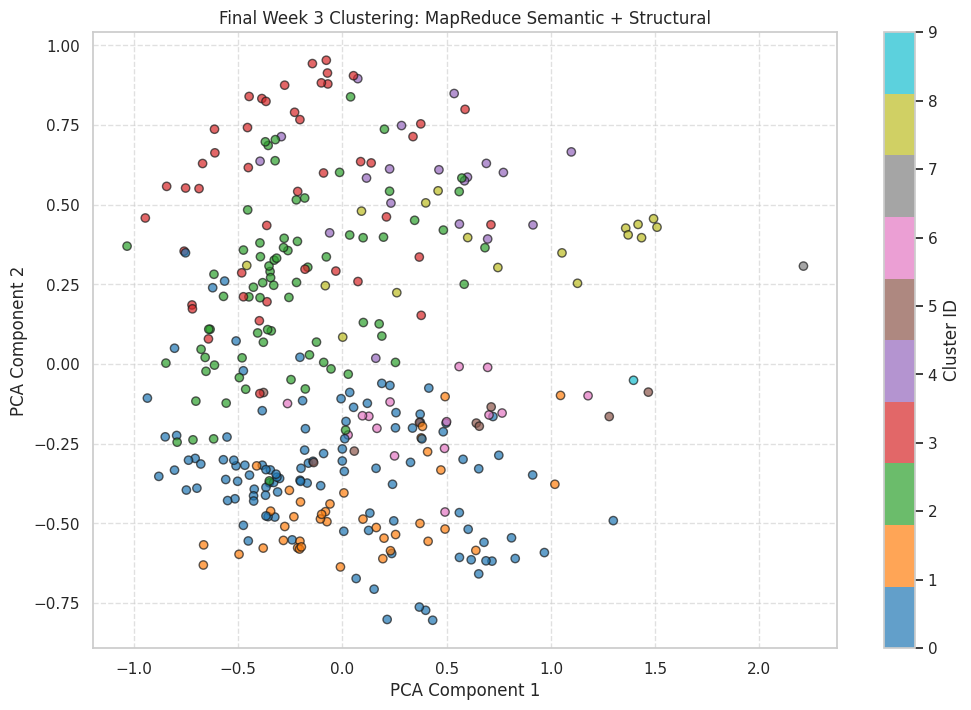

In [113]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Visualization using PCA to project the combined distance matrix into 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(distance_matrix)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='tab10', alpha=0.7, edgecolors='k')
plt.title('Final Week 3 Clustering: MapReduce Semantic + Structural')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

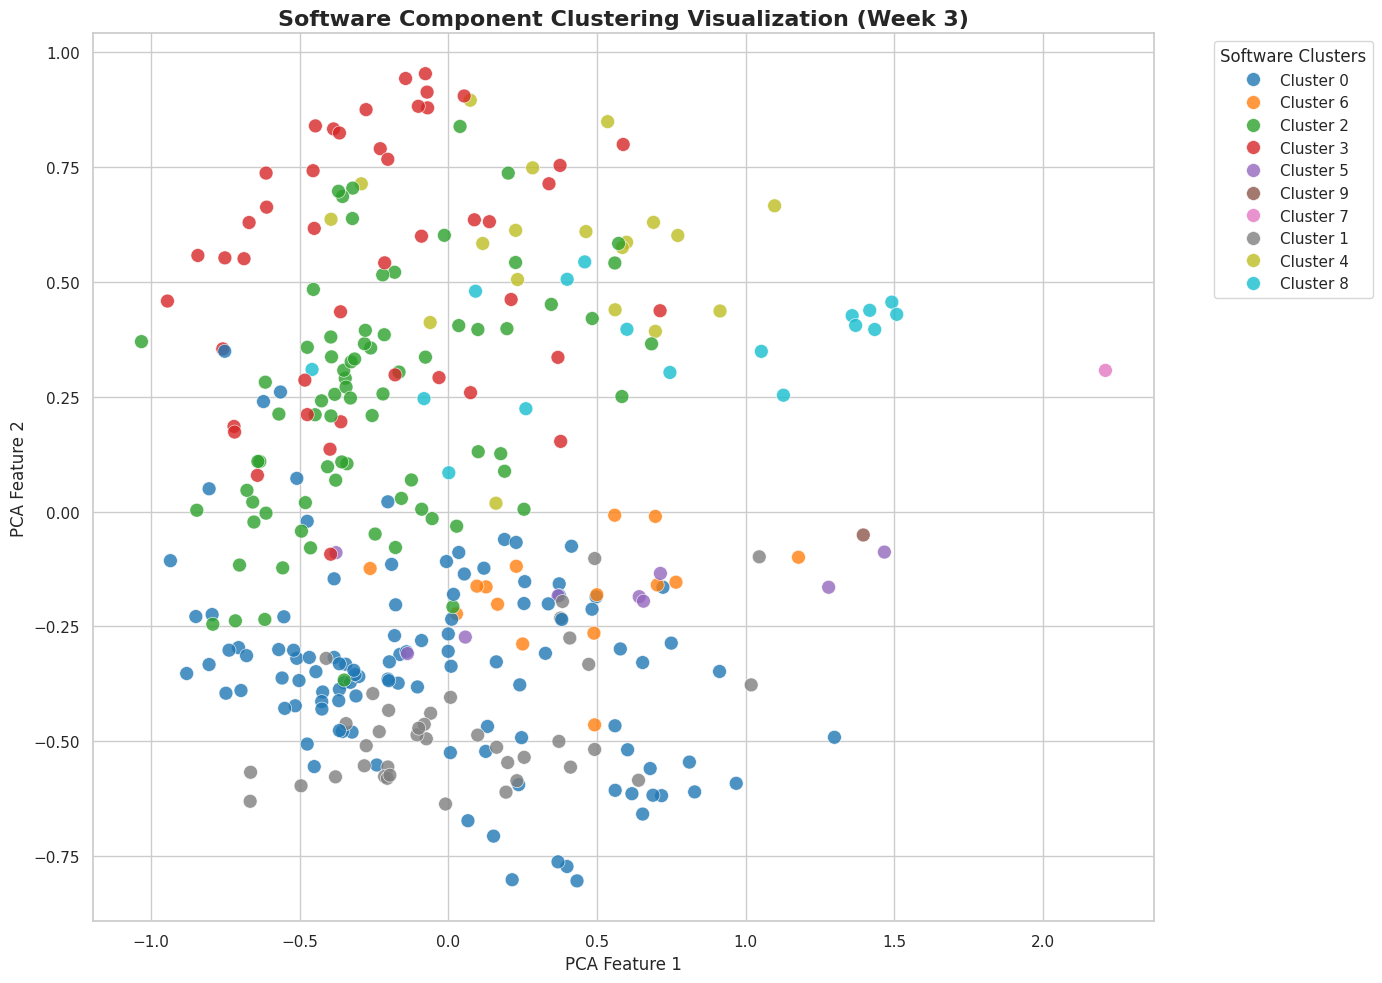

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a more readable dataframe for plotting
plot_df = pd.DataFrame({
    'x': reduced_data[:, 0],
    'y': reduced_data[:, 1],
    'Cluster': [f'Cluster {c}' for c in clusters]
})

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 10))

# Create the scatter plot with a legend
scatter_plot = sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='Cluster',
    palette='tab10',
    s=100,
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Software Component Clustering Visualization (Week 3)', fontsize=16, fontweight='bold')
plt.xlabel('PCA Feature 1', fontsize=12)
plt.ylabel('PCA Feature 2', fontsize=12)

# Move legend to the side for better visibility
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Software Clusters')

plt.tight_layout()
plt.show()

In [100]:
import pandas as pd

# Aligning lengths to avoid ValueError
min_length = min(len(full_class_names), len(clusters))

# Create a mapping of File Name to Cluster ID
results_df = pd.DataFrame({
    'Full_Class_Name': full_class_names[:min_length],
    'Cluster_ID': clusters[:min_length]
})

# Save to the output directory
output_file = OUTPUT_DIR / "clustering_results.csv"
results_df.to_csv(output_file, index=False)

print(f"Results saved to: {output_file}")
print(f"Aligned to {min_length} files.")
display(results_df.head())

Results saved to: /content/output/clustering_results.csv
Aligned to 332 files.


,Full_Class_Name,Cluster_ID
0,org.apache.hadoop.mapreduce.ContextFactory,8
1,org.apache.hadoop.mapreduce.TaskCounter,1
2,org.apache.hadoop.mapreduce.OutputCommitter,5
3,org.apache.hadoop.mapreduce.TaskReport,1
4,org.apache.hadoop.mapreduce.RecordReader,4


In [115]:
# Define the output path for the RSF file
rsf_output_path = OUTPUT_DIR / "final_clustering_using_ibm-granite.rsf"

# Open file and write clustering results in RSF format
# Format: contain <Cluster_ID> <Full_Class_Name>
with open(rsf_output_path, 'w') as f:
    for _, row in results_df.iterrows():
        f.write(f"contain Cluster_{row['Cluster_ID']} {row['Full_Class_Name']}\n")

print(f"RSF file generated successfully at: {rsf_output_path}")

# Display the first few lines of the generated RSF
!head -n 5 {rsf_output_path}

RSF file generated successfully at: /content/output/final_clustering_using_jinaai.rsf
contain Cluster_8 org.apache.hadoop.mapreduce.ContextFactory
contain Cluster_1 org.apache.hadoop.mapreduce.TaskCounter
contain Cluster_5 org.apache.hadoop.mapreduce.OutputCommitter
contain Cluster_1 org.apache.hadoop.mapreduce.TaskReport
contain Cluster_4 org.apache.hadoop.mapreduce.RecordReader
